# **Bank Loan Approval Prediction**




## Upload Dataset

To begin, please upload your dataset.

In [1]:
from google.colab import files
import pandas as pd
import io

# Upload the CSV file
uploaded = files.upload()

# Assuming you upload a single file, get its name
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  # Read the CSV into a pandas DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first 5 rows of the DataFrame
display(df.head())

Saving train_u6lujuX_CVtuZ9i (1).csv to train_u6lujuX_CVtuZ9i (1).csv
User uploaded file "train_u6lujuX_CVtuZ9i (1).csv"


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
print('DataFrame Info:')
df.info()

print('\nDataFrame Description:')
display(df.describe(include='all'))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

DataFrame Description:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


##**1. Data Cleaning & Preprocessing**
Handle missing values, drop unnecessary columns, and encode categorical features.

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy of the dataframe to avoid modifying the original one
df_clean = df.copy()

# 1. Drop Loan_ID as it's a unique identifier and not useful for prediction
if 'Loan_ID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Loan_ID'])

# 2. Handle Missing Values for Categorical columns (fill with mode)
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 3. Handle Missing Values for Numerical columns (fill with median)
df_clean['LoanAmount'] = df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median())

# 4. Encode categorical variables into numeric format
# Binary mapping for simple columns
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})
df_clean['Married'] = df_clean['Married'].map({'Yes': 1, 'No': 0})
df_clean['Education'] = df_clean['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df_clean['Self_Employed'] = df_clean['Self_Employed'].map({'Yes': 1, 'No': 0})
df_clean['Loan_Status'] = df_clean['Loan_Status'].map({'Y': 1, 'N': 0})

# Clean 'Dependents' column (e.g., '3+' becomes 3)
df_clean['Dependents'] = df_clean['Dependents'].replace('3+', 3).astype(int)

# One-hot encoding for multi-category columns like Property_Area
df_clean = pd.get_dummies(df_clean, columns=['Property_Area'], drop_first=True)

print("Data Cleaning & Preprocessing Complete!")
print("Cleaned DataFrame shape:", df_clean.shape)
df_clean.head()

Data Cleaning & Preprocessing Complete!
Cleaned DataFrame shape: (614, 13)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,False,True
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,False,True
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,True
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,False,True


## **2. Split Data & Train the Model**
 Separate our features ($X$) and target ($Y$), split the dataset into training and testing sets, and train a Random Forest Classifier / XGBoost.

In [4]:
# Separate features and target variable
X = df_clean.drop(columns=['Loan_Status'])
y = df_clean['Loan_Status']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## **3. Model Evaluation with Confusion Matrix**
Evaluate model using accuracy, a classification report, and a visual Confusion Matrix.

Model Accuracy: 82.11%

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.61      0.68        38
           1       0.84      0.92      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.76      0.78       123
weighted avg       0.82      0.82      0.81       123



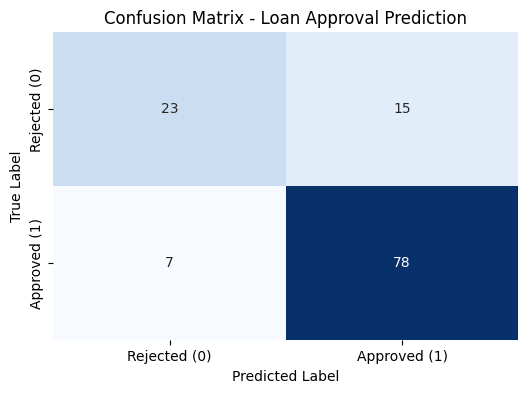

In [5]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Loan Approval Prediction')
plt.show()

## **4. Predict Loan Status for a New Applicant**
Test our pipeline by running a prediction for a new loan applicant.

In [6]:
# Define a sample new applicant matching the feature columns of X_train
# Columns: Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area_Semiurban, Property_Area_Urban
new_applicant = pd.DataFrame([[
    1,    # Gender (1 = Male, 0 = Female)
    1,    # Married (1 = Yes, 0 = No)
    0,    # Dependents
    1,    # Education (1 = Graduate, 0 = Not Graduate)
    0,    # Self_Employed (0 = No, 1 = Yes)
    5000, # ApplicantIncome
    2000, # CoapplicantIncome
    140,  # LoanAmount
    360,  # Loan_Amount_Term
    1.0,  # Credit_History (1.0 = Good, 0.0 = Bad)
    0,    # Property_Area_Semiurban (0 or 1)
    1     # Property_Area_Urban (0 or 1)
]], columns=X_train.columns)

# Predict
prediction = rf_model.predict(new_applicant)
probability = rf_model.predict_proba(new_applicant)

result = "Approved (Y)" if prediction[0] == 1 else "Rejected (N)"
print(f"Prediction for New Applicant: Loan {result}")
print(f"Prediction Probability: Rejected: {probability[0][0]:.2f}, Approved: {probability[0][1]:.2f}")

Prediction for New Applicant: Loan Approved (Y)
Prediction Probability: Rejected: 0.11, Approved: 0.89


#### Performance Breakdown

* **Precision (Class 1 - Approved):** **0.84** — When the model predicts a loan will be approved, it is correct 84% of the time.
* **Recall (Class 1 - Approved):** **0.92** — The model successfully identifies 92% of all actual approved loans in the test set.
* **Class 0 (Rejected):** Lower recall (**0.61**) indicates the model is slightly more conservative, occasionally misclassifying a rejected loan as approved—a common pattern given the class imbalance in credit datasets.

#### Documentation

* **Project Title:** Bank Loan Approval Prediction System
* **Problem Statement:** Automating the loan eligibility process based on customer details (Gender, Marital Status, Income, Credit History, etc.).
* **Data Pipeline Steps:** Missing value imputation (mode for categorical, median for numerical), binary encoding, one-hot encoding for `Property_Area`.
* **Model Selection:** Random Forest Classifier ($n\_estimators=100$) chosen for its robustness against overfitting and handling of mixed data types.
* **Results & Metrics:** Summary table of Accuracy, Precision, Recall, and the Confusion Matrix visualization.